In [ ]:
##  Import Libraries

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
## Load Dataset

In [ ]:
import pandas as pd

df = pd.read_excel(
    r"C:\Users\karth\Downloads\CoffeeShopSales\CoffeeShopSalese.xlsx",
    engine="openpyxl"
)

df.head()

In [ ]:
## Data Cleaning

In [72]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 16 columns):
transaction_id      149116 non-null int64
transaction_date    149116 non-null datetime64[ns]
transaction_time    149116 non-null object
transaction_qty     149116 non-null int64
store_id            149116 non-null int64
store_location      149116 non-null object
product_id          149116 non-null int64
unit_price          149116 non-null float64
product_category    149116 non-null object
product_type        149116 non-null object
product_detail      149116 non-null object
Sales               149116 non-null float64
Month               149116 non-null period[M]
Hour                149116 non-null int64
Time_Period         149116 non-null object
Day_of_Week         149116 non-null object
dtypes: datetime64[ns](1), float64(2), int64(5), object(7), period[M](1)
memory usage: 18.2+ MB
None


In [73]:
print(df.isnull().sum())

transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
Sales               0
Month               0
Hour                0
Time_Period         0
Day_of_Week         0
dtype: int64


In [74]:
print(df.columns)

Index(['transaction_id', 'transaction_date', 'transaction_time',
       'transaction_qty', 'store_id', 'store_location', 'product_id',
       'unit_price', 'product_category', 'product_type', 'product_detail',
       'Sales', 'Month', 'Hour', 'Time_Period', 'Day_of_Week'],
      dtype='object')


In [75]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
transaction_id,149116.0,74737.371872,43153.600016,1.0,37335.75,74727.50,112094.25,149456.0
transaction_qty,149116.0,1.438276,0.542509,1.0,1.00,1.00,2.00,8.0
store_id,149116.0,5.342063,2.074241,3.0,3.00,5.00,8.00,8.0
product_id,149116.0,47.918607,17.930020,1.0,33.00,47.00,60.00,87.0
unit_price,149116.0,3.382219,2.658723,0.8,2.50,3.00,3.75,45.0
Sales,149116.0,4.686367,4.227099,0.8,3.00,3.75,6.00,360.0
Hour,149116.0,11.735790,3.764662,6.0,9.00,11.00,15.00,20.0


In [76]:
df['product_category'].value_counts()

Coffee                58416
Tea                   45449
Bakery                22796
Drinking Chocolate    11468
Flavours               6790
Coffee beans           1753
Loose Tea              1210
Branded                 747
Packaged Chocolate      487
Name: product_category, dtype: int64

In [77]:
df['product_type'].value_counts()

Brewed Chai tea          17183
Gourmet brewed coffee    16912
Barista Espresso         16403
Hot chocolate            11468
Brewed Black tea         11350
Brewed herbal tea        11245
Scone                    10173
Organic brewed coffee     8489
Drip coffee               8477
Premium brewed coffee     8135
Pastry                    6912
Biscotti                  5711
Brewed Green tea          5671
Regular syrup             4979
Sugar free syrup          1811
Housewares                 526
Chai tea                   443
Organic Beans              415
Gourmet Beans              366
Premium Beans              336
Espresso Beans             319
Herbal tea                 305
Black tea                  303
Drinking Chocolate         266
Organic Chocolate          221
Clothing                   221
House blend Beans          183
Green tea                  159
Green beans                134
Name: product_type, dtype: int64

In [78]:
## Feature Engineering

In [79]:
df['product_category'].value_counts()*100/len(df)

Coffee                39.174871
Tea                   30.478956
Bakery                15.287427
Drinking Chocolate     7.690657
Flavours               4.553502
Coffee beans           1.175595
Loose Tea              0.811449
Branded                0.500952
Packaged Chocolate     0.326591
Name: product_category, dtype: float64

In [80]:
df[['product_type','unit_price']].head()

,product_type,unit_price
0,Gourmet brewed coffee,3.0
1,Brewed Chai tea,3.1
2,Hot chocolate,4.5
3,Drip coffee,2.0
4,Brewed Chai tea,3.1


In [81]:
df['Sales'] = df['transaction_qty'] * df['unit_price']

In [82]:
sales_by_product = df.groupby('product_type')['Sales'].sum().sort_values(ascending=False)
print(sales_by_product)

product_type
Barista Espresso         91406.20
Brewed Chai tea          77081.95
Hot chocolate            72416.00
Gourmet brewed coffee    70034.60
Brewed Black tea         47932.00
Brewed herbal tea        47539.50
Premium brewed coffee    38781.15
Organic brewed coffee    37746.50
Scone                    36866.12
Drip coffee              31984.00
Pastry                   25655.99
Brewed Green tea         23852.50
Biscotti                 19793.53
Premium Beans            14583.50
Organic Beans             8509.50
Housewares                7444.00
Gourmet Beans             6798.00
Clothing                  6163.00
Regular syrup             6084.80
Espresso Beans            5560.25
Chai tea                  4301.25
House blend Beans         3294.00
Herbal tea                2729.75
Drinking Chocolate        2728.04
Black tea                 2711.85
Sugar free syrup          2324.00
Organic Chocolate         1679.60
Green tea                 1470.75
Green beans               1340.00
N

In [83]:
sales_by_category = df.groupby('product_category')['Sales'].sum().sort_values(ascending=False)
print(sales_by_category)

product_category
Coffee                269952.45
Tea                   196405.95
Bakery                 82315.64
Drinking Chocolate     72416.00
Coffee beans           40085.25
Branded                13607.00
Loose Tea              11213.60
Flavours                8408.80
Packaged Chocolate      4407.64
Name: Sales, dtype: float64


In [84]:
sales_by_location= df.groupby('store_location')['Sales'].sum().sort_values(ascending=False)
print(sales_by_location)

store_location
Hell's Kitchen     236511.17
Astoria            232243.91
Lower Manhattan    230057.25
Name: Sales, dtype: float64


In [85]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Sales,Month,Hour,Time_Period,Day_of_Week
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,2023-01,7,Morning,Sunday
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,2023-01,7,Morning,Sunday
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,2023-01,7,Morning,Sunday
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,2023-01,7,Morning,Sunday
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,2023-01,7,Morning,Sunday


In [86]:
pd.crosstab(index=df["product_type"],columns=df["product_category"])

product_category,Bakery,Branded,Coffee,Coffee beans,Drinking Chocolate,Flavours,Loose Tea,Packaged Chocolate,Tea
product_type,,,,,,,,,
Barista Espresso,0,0,16403,0,0,0,0,0,0
Biscotti,5711,0,0,0,0,0,0,0,0
Black tea,0,0,0,0,0,0,303,0,0
Brewed Black tea,0,0,0,0,0,0,0,0,11350
Brewed Chai tea,0,0,0,0,0,0,0,0,17183
Brewed Green tea,0,0,0,0,0,0,0,0,5671
Brewed herbal tea,0,0,0,0,0,0,0,0,11245
Chai tea,0,0,0,0,0,0,443,0,0
Clothing,0,221,0,0,0,0,0,0,0


In [87]:
df['Sales'] = df['transaction_qty'] * df['unit_price']
monthly_sales = df.groupby(df['transaction_date'].dt.to_period('M'))['Sales'].sum()

print(monthly_sales)

transaction_date
2023-01     81677.74
2023-02     76145.19
2023-03     98834.68
2023-04    118941.08
2023-05    156727.76
2023-06    166485.88
Freq: M, Name: Sales, dtype: float64


In [88]:
df['Month'] = df['transaction_date'].dt.to_period('M')
monthly_product_sales = (df.groupby(['Month', 'product_category'])['Sales'].sum().reset_index())

print(monthly_product_sales)

      Month    product_category     Sales
0   2023-01              Bakery   9535.75
1   2023-01             Branded   1890.00
2   2023-01              Coffee  31256.85
3   2023-01        Coffee beans   5245.25
4   2023-01  Drinking Chocolate   8337.75
5   2023-01            Flavours    974.40
6   2023-01           Loose Tea   1293.85
7   2023-01  Packaged Chocolate    521.94
8   2023-01                 Tea  22621.95
9   2023-02              Bakery   9038.82
10  2023-02             Branded   1235.00
11  2023-02              Coffee  29268.95
12  2023-02        Coffee beans   4077.50
13  2023-02  Drinking Chocolate   8132.25
14  2023-02            Flavours    930.40
15  2023-02           Loose Tea   1277.85
16  2023-02  Packaged Chocolate    451.02
17  2023-02                 Tea  21733.40
18  2023-03              Bakery  11902.58
19  2023-03             Branded   1801.00
20  2023-03              Coffee  38303.60
21  2023-03        Coffee beans   5256.20
22  2023-03  Drinking Chocolate  1

In [89]:
df['Month'] = df['transaction_date'].dt.to_period('M')
monthly_product_sales = (df.groupby(['Month', 'product_category'])['Sales'].sum().reset_index())
monthly_product_sales = (
    df.groupby(['Month', 'product_type'])['Sales']
    .sum()
    .reset_index()
)

result = monthly_product_sales.loc[
    monthly_product_sales.groupby('Month')['Sales'].idxmax()
]

print(result)

       Month      product_type     Sales
0    2023-01  Barista Espresso  10461.20
29   2023-02  Barista Espresso  10027.15
58   2023-03  Barista Espresso  13078.20
87   2023-04  Barista Espresso  15555.90
116  2023-05  Barista Espresso  20423.75
145  2023-06  Barista Espresso  21860.00


In [90]:
df['Month'] = df['transaction_date'].dt.to_period('M')
monthly_product_sales = (df.groupby(['Month', 'product_category'])['Sales'].sum().reset_index())
monthly_product_sales = (
    df.groupby(['Month', 'product_type'])['Sales']
    .sum()
    .reset_index()
)

result = monthly_product_sales.loc[
    monthly_product_sales.groupby('Month')['Sales'].idxmin()
]

print(result)

       Month product_type   Sales
15   2023-01    Green tea  185.00
44   2023-02    Green tea  157.25
72   2023-03  Green beans  190.00
101  2023-04  Green beans  210.00
130  2023-05  Green beans  290.00
159  2023-06  Green beans  250.00


In [91]:
df['Month'] = df['transaction_date'].dt.to_period('M')
monthly_product_sales = (df.groupby(['Month', 'store_location'])['Sales'].sum().reset_index())
monthly_product_sales = (
    df.groupby(['Month', 'store_location'])['Sales']
    .sum()
    .reset_index()
)

result = monthly_product_sales.loc[
    monthly_product_sales.groupby('Month')['Sales'].idxmax()
]

print(result)

      Month  store_location     Sales
1   2023-01  Hell's Kitchen  27820.65
4   2023-02  Hell's Kitchen  25719.80
7   2023-03  Hell's Kitchen  33110.57
10  2023-04  Hell's Kitchen  40304.14
13  2023-05  Hell's Kitchen  52598.93
16  2023-06  Hell's Kitchen  56957.08


In [92]:
df['Month'] = df['transaction_date'].dt.to_period('M')
monthly_product_sales = (df.groupby(['Month', 'store_location'])['Sales'].sum().reset_index())
monthly_product_sales = (df.groupby(['Month', 'store_location'])['Sales'].sum().reset_index())

result = monthly_product_sales.loc[
    monthly_product_sales.groupby('Month')['Sales'].idxmin()
]

print(result)


      Month   store_location     Sales
2   2023-01  Lower Manhattan  26543.43
3   2023-02          Astoria  25105.34
6   2023-03          Astoria  32835.43
11  2023-04  Lower Manhattan  39159.33
14  2023-05  Lower Manhattan  51700.07
17  2023-06  Lower Manhattan  54445.69


In [93]:
df['Month'] = df['transaction_date'].dt.to_period('M')
monthly_product_sales = (df.groupby(['Month', 'product_category'])['Sales'].sum().reset_index())
monthly_product_sales = (
    df.groupby(['Month', 'product_category'])['Sales']
    .sum()
    .reset_index()
)

result = monthly_product_sales.loc[
    monthly_product_sales.groupby('Month')['Sales'].idxmax()
]

print(result)

      Month product_category     Sales
2   2023-01           Coffee  31256.85
11  2023-02           Coffee  29268.95
20  2023-03           Coffee  38303.60
29  2023-04           Coffee  45971.20
38  2023-05           Coffee  60362.85
47  2023-06           Coffee  64789.00


In [94]:
df['Month'] = df['transaction_date'].dt.to_period('M')
monthly_product_sales = (df.groupby(['Month', 'product_category'])['Sales'].sum().reset_index())
monthly_product_sales = (
    df.groupby(['Month', 'product_category'])['Sales']
    .sum()
    .reset_index()
)

result = monthly_product_sales.loc[
    monthly_product_sales.groupby('Month')['Sales'].idxmin()
]

print(result)

      Month    product_category   Sales
7   2023-01  Packaged Chocolate  521.94
16  2023-02  Packaged Chocolate  451.02
25  2023-03  Packaged Chocolate  588.20
34  2023-04  Packaged Chocolate  873.23
43  2023-05  Packaged Chocolate  981.09
52  2023-06  Packaged Chocolate  992.16


In [95]:
df['Hour'] = df['transaction_time'].apply(lambda x: x.hour)
hourly_sales = df.groupby('Hour')['Sales'].sum().sort_values(ascending=False)
peak_hour = hourly_sales.idxmax()
peak_sales = hourly_sales.max()

print(f"Peak Hour: {peak_hour}:00")
print(f"Sales: {peak_sales:.2f}")


Peak Hour: 10:00
Sales: 88673.39


In [96]:
df['Hour'] = df['transaction_time'].apply(lambda x: x.hour)

def time_period(hour):
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    else:
        return 'Evening'

df['Time_Period'] = df['Hour'].apply(time_period)

sales_by_period = df.groupby('Time_Period')['Sales'].sum()

print(sales_by_period)

Time_Period
Afternoon    204720.83
Evening      105802.83
Morning      388288.67
Name: Sales, dtype: float64


In [97]:
## What Times of Day Are Most Popular?

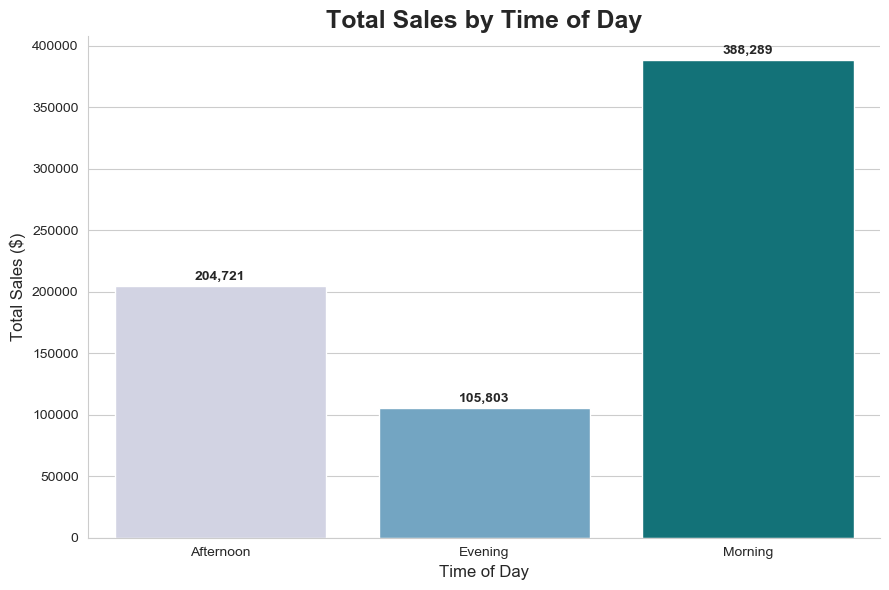

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

plt.figure(figsize=(9,6))

ax = sns.barplot(
    x=sales_by_period.index,
    y=sales_by_period.values,
    palette="PuBuGn"
)

plt.title("Total Sales by Time of Day",
          fontsize=18,
          fontweight='bold')

plt.xlabel("Time of Day", fontsize=12)
plt.ylabel("Total Sales ($)", fontsize=12)

# Value labels
for i, value in enumerate(sales_by_period.values):
    ax.text(
        i,
        value + 5000,
        f'{value:,.0f}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

# Remove top and right border
sns.despine()

plt.tight_layout()
plt.show()

In [99]:
## Monthly Sales Trend

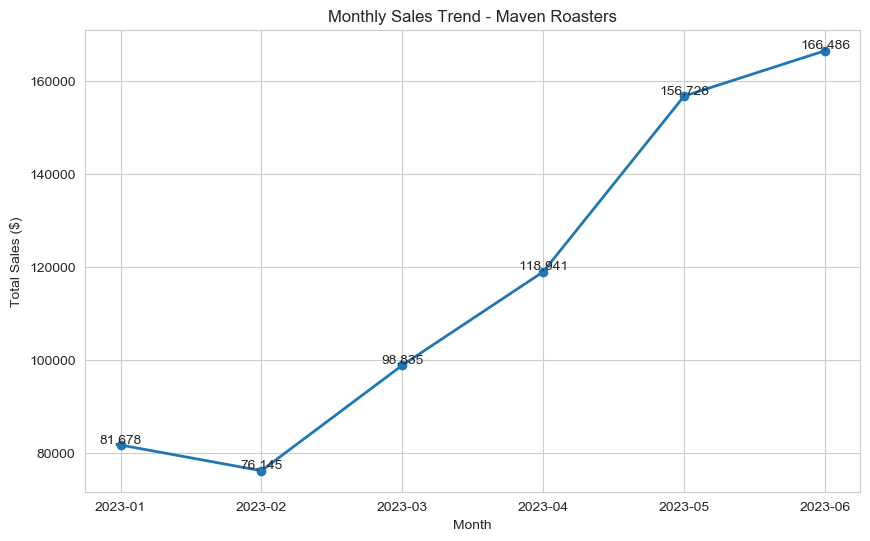

In [100]:
import matplotlib.pyplot as plt

df['Sales'] = df['transaction_qty'] * df['unit_price']

df['Month'] = df['transaction_date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(10,6))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker='o', linewidth=2)

plt.title('Monthly Sales Trend - Maven Roasters')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.grid(True)

for x, y in zip(monthly_sales.index.astype(str), monthly_sales.values):
    plt.text(x, y, f'{y:,.0f}', ha='center', va='bottom')

plt.show()

In [101]:
##  Which Days of the Week Are Busiest?

In [102]:
df['Day_of_Week'] = df['transaction_date'].dt.day_name()
daily_sales = ( df.groupby('Day_of_Week')['Sales'].sum())
days_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

daily_sales = daily_sales.reindex(days_order)

print(daily_sales)

Day_of_Week
Monday       101677.28
Tuesday       99455.94
Wednesday    100313.54
Thursday     100767.78
Friday       101373.00
Saturday      96894.48
Sunday        98330.31
Name: Sales, dtype: float64


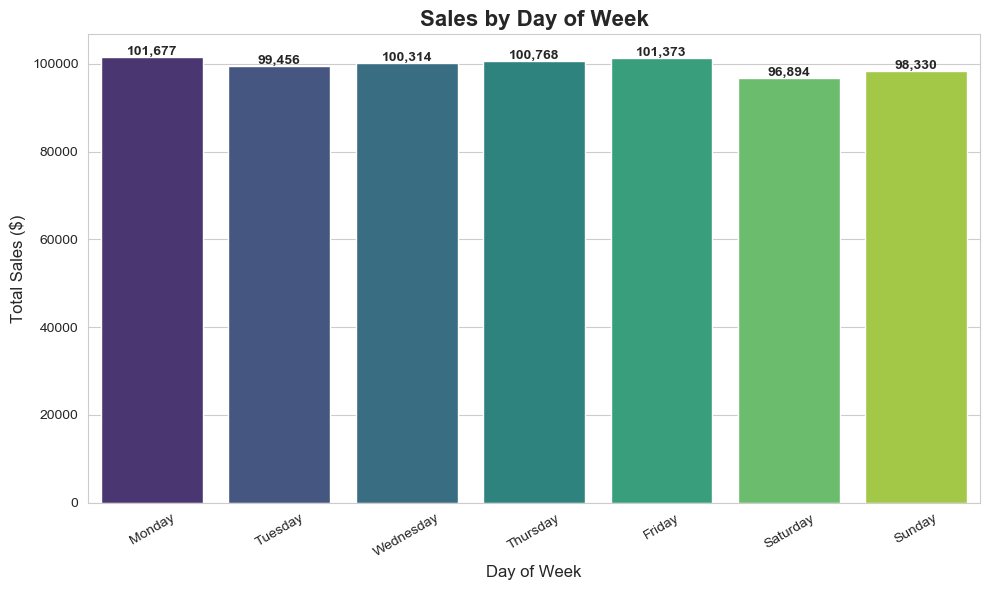

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=daily_sales.index,
    y=daily_sales.values,
    palette="viridis"
)

plt.title("Sales by Day of Week", fontsize=16, fontweight='bold')
plt.xlabel("Day of Week", fontsize=12)
plt.ylabel("Total Sales ($)", fontsize=12)
plt.xticks(rotation=30)

for i, value in enumerate(daily_sales.values):
    ax.text(
        i,
        value + 500,
        f'{value:,.0f}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [104]:
##  What Times of Day Are Most Popular?

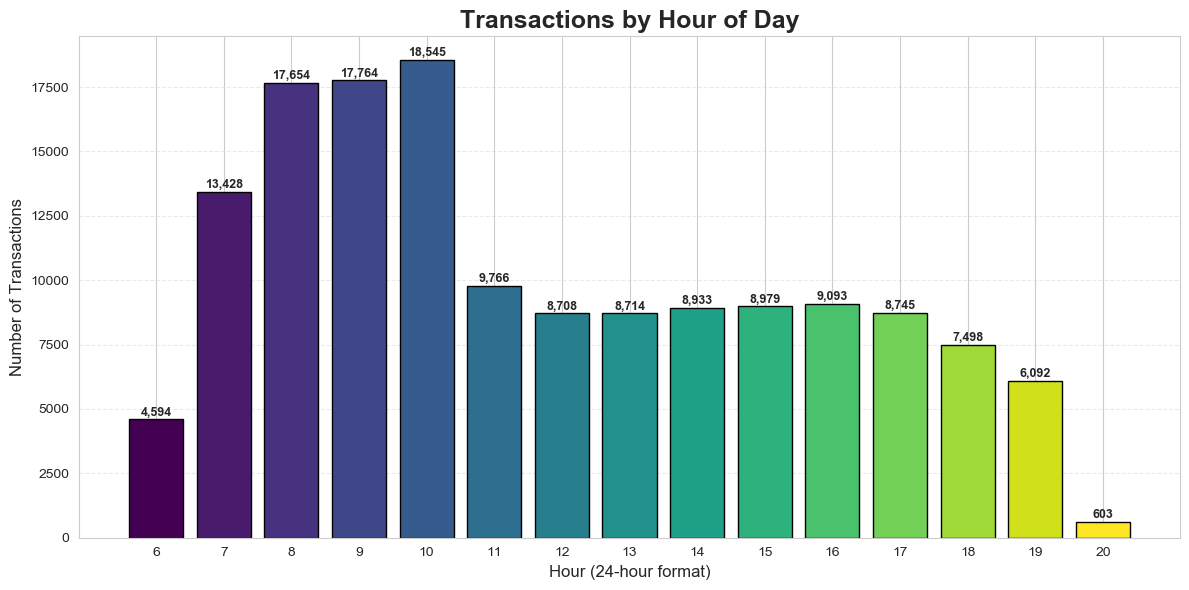

In [105]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,6))

# Generate different colors for each bar
colors = plt.cm.viridis(np.linspace(0, 1, len(hourly_transactions)))

bars = plt.bar(
    hourly_transactions.index,
    hourly_transactions.values,
    color=colors,
    edgecolor='black',
    linewidth=1
)

plt.title("Transactions by Hour of Day", fontsize=18, fontweight='bold')
plt.xlabel("Hour (24-hour format)", fontsize=12)
plt.ylabel("Number of Transactions", fontsize=12)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 150,
        f'{int(height):,}',
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(hourly_transactions.index)

plt.tight_layout()
plt.show()


In [106]:
## what product has highest product revenue ?
product_revenue = (
    df.groupby('product_type')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(product_revenue)

product_type
Barista Espresso         91406.20
Brewed Chai tea          77081.95
Hot chocolate            72416.00
Gourmet brewed coffee    70034.60
Brewed Black tea         47932.00
Brewed herbal tea        47539.50
Premium brewed coffee    38781.15
Organic brewed coffee    37746.50
Scone                    36866.12
Drip coffee              31984.00
Name: Sales, dtype: float64


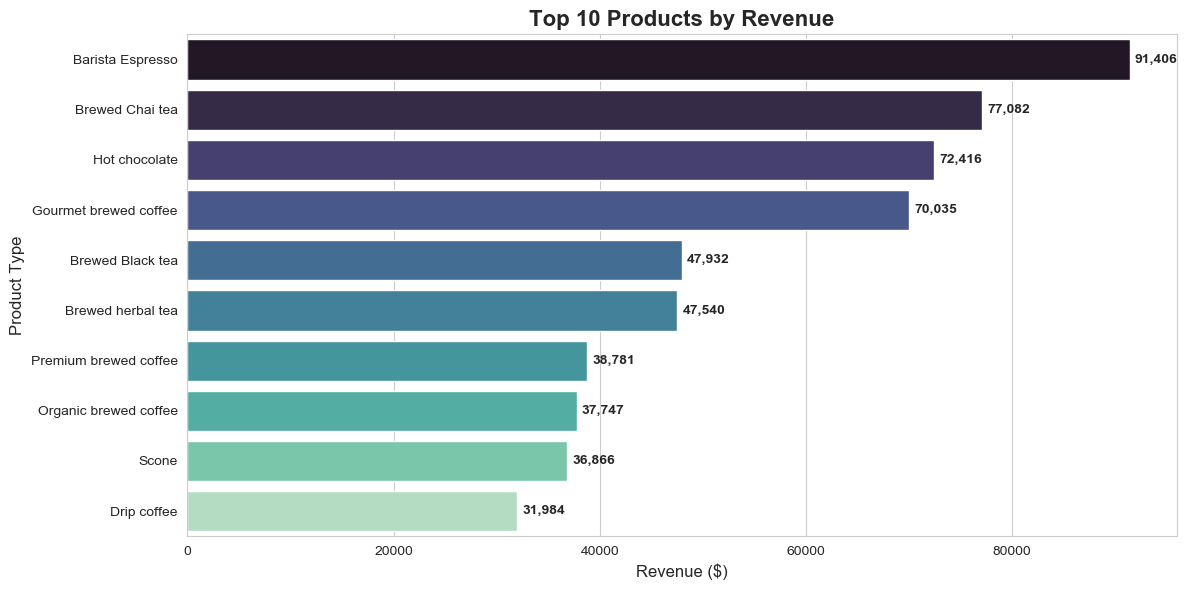

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=product_revenue.values,
    y=product_revenue.index,
    palette="mako"
)

plt.title("Top 10 Products by Revenue", fontsize=16, fontweight="bold")
plt.xlabel("Revenue ($)", fontsize=12)
plt.ylabel("Product Type", fontsize=12)

for i, value in enumerate(product_revenue.values):
    ax.text(
        value + 500,
        i,
        f'{value:,.0f}',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [108]:
## Peak Hours

In [111]:
peak_hours = location_hour.loc[
    location_hour.groupby('store_location')['Transactions'].idxmax()
]

print(peak_hours)

     store_location  Hour  Transactions
3           Astoria    10          5291
17   Hell's Kitchen    10          6957
32  Lower Manhattan    10          6297


In [112]:
## Which products are sold most and least often?

In [113]:
product_qty = (
    df.groupby('product_type')['transaction_qty']
    .sum()
    .sort_values(ascending=False)
)

print(product_qty)

product_type
Brewed Chai tea          26250
Gourmet brewed coffee    25973
Barista Espresso         24943
Brewed Black tea         17462
Hot chocolate            17457
Brewed herbal tea        17328
Organic brewed coffee    13012
Drip coffee              12891
Premium brewed coffee    12431
Scone                    10465
Brewed Green tea          8697
Regular syrup             7606
Pastry                    6961
Biscotti                  5788
Sugar free syrup          2905
Housewares                 555
Chai tea                   443
Organic Beans              420
Premium Beans              406
Gourmet Beans              366
Espresso Beans             319
Herbal tea                 305
Black tea                  303
Drinking Chocolate         266
Clothing                   221
Organic Chocolate          221
House blend Beans          183
Green tea                  159
Green beans                134
Name: transaction_qty, dtype: int64


In [114]:
print(product_qty.tail(10))

product_type
Gourmet Beans         366
Espresso Beans        319
Herbal tea            305
Black tea             303
Drinking Chocolate    266
Clothing              221
Organic Chocolate     221
House blend Beans     183
Green tea             159
Green beans           134
Name: transaction_qty, dtype: int64


# Key Insights

1. Sales increased steadily from January to June, with June recording the highest revenue.

2. Monday and Friday generated the highest sales, while Saturday had the lowest.

3. Morning hours, especially around 10 AM, had the highest customer traffic.

4. All three store locations experienced their peak transactions at 10 AM.

5. Coffee and Tea products contributed the largest share of revenue.

6. Green Beans, Green Tea, and House Blend Beans were the least sold products.

# Conclusion

This project analyzed Maven Roasters' coffee shop sales data using Python (Pandas and Matplotlib) to uncover sales trends, customer purchasing behavior, and product performance. The analysis showed steady sales growth from January to June, with peak customer activity occurring during the morning hours, especially at 10 AM, across all store locations. Coffee and Tea products emerged as the primary revenue drivers, while several specialty products had relatively low demand. These insights can help the business optimize staffing, inventory management, and promotional strategies to improve overall sales performance.